# **Machine Learning Project 1**
## AI Detection Tools: Investigating Whether NLP Models Learn Writing Style or Topic Bias
### Phillip Vogt

## Overview
As artificial intelligence continues to develop, detecting and flagging AI generated content is becoming an increasingly difficult challenge because large language models are designed to produce outputs that closely mimic that of human writing. Being able to accurately flag AI generated content is an important problem to solve not just for ensuring academic integrity but also for verifying content.




**Research Question: What is more effective at detecting AI-generated text? Analyzing the words and topics using TF-IDF, analyzing writing style patterns, or combining the two? And do different model types (Naive Bayes vs. Logistic Regression) perform differently on this task?**




This project analyzes a [Kaggle](https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text?resource=download) dataset of 500,000 essays labeled as either human written or AI generated. The goal is to use scikit-learn's TF-IDF vectorizer, an NLP tool, to convert raw text into numerical features based on the word importance and then train classifiers to distinguish between the two classes. The model will also extract style features such as sentence length, lexical diversity, and punctuation patterns to capture the writing style separately from the topic. By training four different models across three different feature setups, we can see which approach works best and figure out whether the model's accuracy comes from detecting real writing style differences or just from recognizing which topics each class tends to write about.



In [ ]:
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')
path = "/content/drive/MyDrive/Machine Learning/AI_Human.csv"
df = pd.read_csv(path)

print(df.head())
print(df.columns)
print(df.shape)

Mounted at /content/drive
                                                text  generated
0  Cars. Cars have been around since they became ...        0.0
1  Transportation is a large necessity in most co...        0.0
2  "America's love affair with it's vehicles seem...        0.0
3  How often do you ride in a car? Do you drive a...        0.0
4  Cars are a wonderful thing. They are perhaps o...        0.0
Index(['text', 'generated'], dtype='object')
(487235, 2)


## Data Cleaning and Preprocessing

We rename the target column to make it more readable, drop any rows that have missing text, and take a random sample of 120,000 essays for computational efficiency. The model uses stratification so that both the training and test sets have the same ratio of human to AI essays, since the dataset is imbalanced (about 63% human, 37% AI).

In [ ]:
from sklearn.model_selection import train_test_split

df = df.rename(columns={'generated': 'label'})
df['label']=df['label'].astype(int)
df = df.dropna(subset=['text'])
df_sample = df.sample(n=120000, random_state=42)
X = df_sample['text']
y =df_sample['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set size: 96000
Test set size: 24000

Training label distribution:
label
0    0.627
1    0.373
Name: proportion, dtype: float64

Test label distribution:
label
0    0.627
1    0.373
Name: proportion, dtype: float64


## Exploratory Data Analysis

Before building any models we need to understand what the data actually looks like. We check the class balance to see how many essays are human vs AI, and plot the word count distributions for each class.

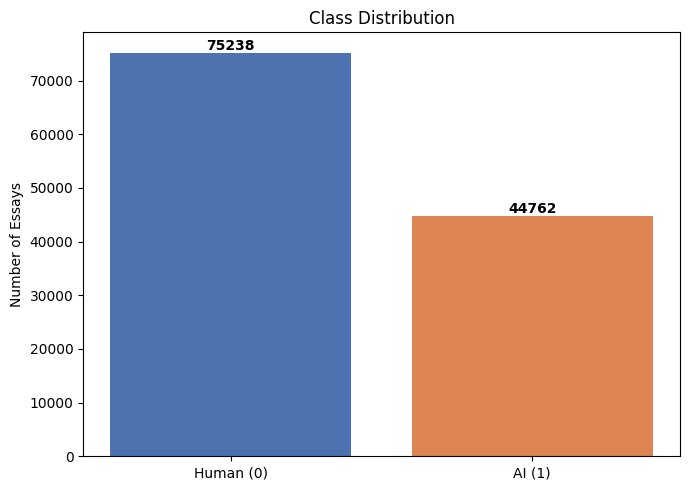

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts =df_sample['label'].value_counts()
plt.figure(figsize=(7, 5))
plt.bar(['Human (0)', 'AI (1)'], label_counts.values, color=['#4C72B0', '#DD8452'])
plt.title('Class Distribution')
plt.ylabel('Number of Essays')
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 500, str(v), ha ='center', fontweight= 'bold')
plt.tight_layout()
plt.show()

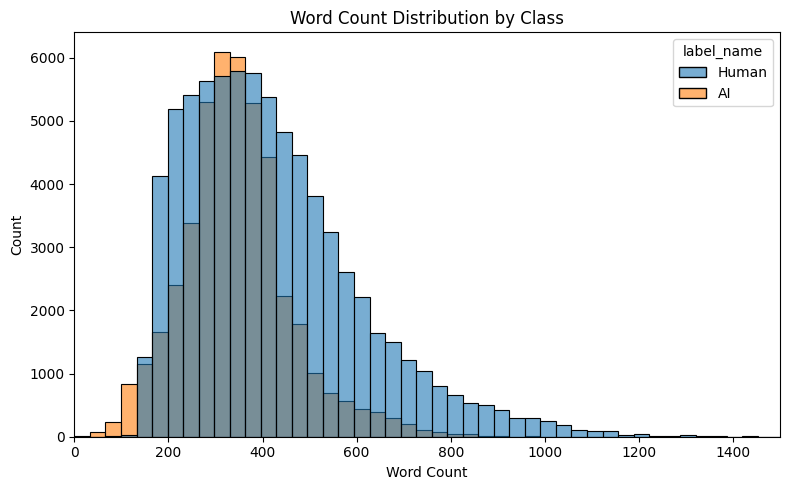


Word count statistics by class:
              count   mean    std   min    25%    50%    75%     max
label_name                                                          
AI          44762.0  344.9  116.4   0.0  274.0  337.0  403.0  1097.0
Human       75238.0  421.5  186.7  48.0  281.0  389.0  519.0  1651.0


In [ ]:
df_sample['word_count'] = df_sample['text'].apply(lambda x: len(str(x).split()))
df_sample['label_name'] = df_sample['label'].map({0: 'Human', 1: 'AI'})

plt.figure(figsize=(8, 5))
sns.histplot(data=df_sample, x= 'word_count', hue = 'label_name', bins = 50, alpha=0.6)
plt.title('Word Count Distribution by Class')
plt.xlabel('Word Count')
plt.xlim(0, 1500)
plt.tight_layout()
plt.show()

print("\nWord count statistics by class:")
print(df_sample.groupby('label_name')['word_count'].describe().round(1))

The word count distributions show that human essays tend to be a bit longer on average than AI essays, but there's a lot of overlap between the two. Word count alone  isn't enough to classify them, but could still be a contributing feature.

##Model Building

The model will extract seven new features that capture writing style independent of the topic being written about. The idea is that these measure how the text is written not what it's about.

- **num_words**: Total word count
- **avg_word_length**: Average characters per word
- **avg_sentence_length**: Average words per sentence
- **num_exclamations**: Number of exclamation marks (emotional expression)
- **num_questions**: Number of question marks (rhetorical engagement)
- **num_uppercase**: Number of uppercase characters (patterns)
- **lexical_diversity**: Ratio of unique words to total words (vocabulary)

In [ ]:
import numpy as np
import re

def extract_features(text):
    text =str(text)
    words = text.split()
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if s.strip()]

    num_words = len(words)
    num_sentences=len(sentences) if sentences else 1

    avg_word_length=np.mean([len(word) for word in words]) if words else 0
    avg_sentence_length = num_words / num_sentences if num_sentences > 0 else 0

    num_exclamations =text.count('!')
    num_questions = text.count('?')
    num_uppercase=sum(1 for c in text if c.isupper())

    unique_words = len(set(w.lower() for w in words))
    lexical_diversity = unique_words / num_words if num_words > 0 else 0

    return [
        num_words, avg_word_length, avg_sentence_length,
        num_exclamations, num_questions, num_uppercase, lexical_diversity]

X_train_style = np.array([extract_features(t) for t in X_train])
X_test_style = np.array([extract_features(t) for t in X_test])

print("Stylometric features shape (train):", X_train_style.shape)
print("Stylometric features shape (test):", X_test_style.shape)
print("Features: [num_words, avg_word_length, avg_sentence_length, num_exclamations, num_questions, num_uppercase, lexical_diversity]")

Stylometric features shape (train): (96000, 7)
Stylometric features shape (test): (24000, 7)
Features: [num_words, avg_word_length, avg_sentence_length, num_exclamations, num_questions, num_uppercase, lexical_diversity]


TF-IDF converts raw text into numerical vectors based on how important each word is across the dataset. Unlike the style features, TF-IDF captures the topic of the text and the specific words and word pairs that are used. We set it up with stopword removal, a max vocabulary of 15,000 features, and an n-gram range of (1,2) so it picks up both single words and certain word pairs.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

vectorizer = TfidfVectorizer(stop_words='english', max_features=15000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

X_train_combined = hstack([X_train_tfidf, X_train_style])
X_test_combined = hstack([X_test_tfidf, X_test_style])

print("TF-IDF features shape:", X_train_tfidf.shape)
print("Combined features shape:", X_train_combined.shape)

TF-IDF features shape: (96000, 15000)
Combined features shape: (96000, 15007)


To answer our research question about whether the model learns better with style or topic, we train four separate models using different feature combinations.

1. **Naive Bayes with TF-IDF:** tests on word content alone
2. **Naive Bayes with style features:** tests on style content alone
3. **Naive Bayes with combined features:** uses both TF-IDF word content and style features together
4. **Logistic Regression with combined features:** a second model type to make sure results aren't just specific to Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

scaler = MinMaxScaler()
X_train_style_scaled =scaler.fit_transform(X_train_style)
X_test_style_scaled=scaler.transform(X_test_style)

X_train_combined = hstack([X_train_tfidf, X_train_style_scaled])
X_test_combined =hstack([X_test_tfidf, X_test_style_scaled])

#TF IDF
model_tfidf =MultinomialNB()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf= model_tfidf.predict(X_test_tfidf)
acc_tfidf=accuracy_score(y_test, y_pred_tfidf)

#Stylometric
model_style = MultinomialNB()
model_style.fit(X_train_style_scaled, y_train)
y_pred_style = model_style.predict(X_test_style_scaled)
acc_style=accuracy_score(y_test, y_pred_style)

#Combined (Naive Bayes)
model_combined = MultinomialNB()
model_combined.fit(X_train_combined, y_train)
y_pred_combined = model_combined.predict(X_test_combined)
acc_combined=accuracy_score(y_test, y_pred_combined)

#Combined (Logistic Regression)
model_lr=LogisticRegression(max_iter=1000,random_state=42)
model_lr.fit(X_train_combined, y_train)
y_pred_lr=model_lr.predict(X_test_combined)
acc_lr=accuracy_score(y_test, y_pred_lr)

print("Test Set Accuracy Comparison:")
print(f"NB TF-IDF Only:      {acc_tfidf:.4f}")
print(f"NB Stylometric Only: {acc_style:.4f}")
print(f"NB Combined:         {acc_combined:.4f}")
print(f"LR Combined:         {acc_lr:.4f}")

Test Set Accuracy Comparison:
NB TF-IDF Only:      0.9637
NB Stylometric Only: 0.6270
NB Combined:         0.9640
LR Combined:         0.9898


The results here directly answer the research question. The TF-IDF only model gets almost the same accuracy as the combined model, which means word content alone is enough to classify most of the essays. Style features barely add anything to the model. The style only model does noticeably worse, showing that writing style differences between human and AI text are more subtle and harder to pick up on than topic differences.

##Model Evaluation

Now we look at the full classification report for the primary combined Naive Bayes model.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model = model_combined
y_pred = y_pred_combined

print("Combined Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Combined Naive Bayes Classification Report:
              precision    recall  f1-score   support

       Human       0.97      0.98      0.97     15048
          AI       0.96      0.94      0.95      8952

    accuracy                           0.96     24000
   macro avg       0.96      0.96      0.96     24000
weighted avg       0.96      0.96      0.96     24000


Confusion Matrix:
[[14689   359]
 [  504  8448]]


### Top TF-IDF Words
These words are the most strongly associated with each class based on the TF-IDF-only model. Since this model only sees word content, it shows us exactly which topics are driving the classification.

In [ ]:
import numpy as np

tfidf_features=vectorizer.get_feature_names_out()
log_prob_diff =model_tfidf.feature_log_prob_[1] - model_tfidf.feature_log_prob_[0]

top_ai_idx= np.argsort(log_prob_diff)[-15:]
top_human_idx= np.argsort(log_prob_diff)[:15]

print("Top 15 TF-IDF words associated with AI-generated text:")
for idx in reversed(top_ai_idx):
    print(f"  {tfidf_features[idx]:25s}  (log-prob diff: {log_prob_diff[idx]:.4f})")

print("\nTop 15 TF-IDF words associated with Human-written text:")
for idx in top_human_idx:
    print(f"  {tfidf_features[idx]:25s}  (log-prob diff: {log_prob_diff[idx]:.4f})")

Top 15 TF-IDF words associated with AI-generated text:
  university education       (log-prob diff: 5.1411)
  writing express            (log-prob diff: 4.8659)
  like super                 (log-prob diff: 4.8378)
  zoos                       (log-prob diff: 4.8365)
  tour guide                 (log-prob diff: 4.7822)
  broad knowledge            (log-prob diff: 4.7736)
  support abolishing         (log-prob diff: 4.7099)
  public health              (log-prob diff: 4.6808)
  today express              (log-prob diff: 4.6219)
  personal growth            (log-prob diff: 4.5972)
  sustainable                (log-prob diff: 4.5894)
  informed decisions         (log-prob diff: 4.5862)
  dictionaries               (log-prob diff: 4.5239)
  encourages candidates      (log-prob diff: 4.5219)
  urge support               (log-prob diff: 4.5143)

Top 15 TF-IDF words associated with Human-written text:
  student_name               (log-prob diff: -4.2689)
  driveless                  (log-prob 

### Stylometric Feature Comparison

Now we look at the style features separately to see if there are real style differences in how human and AI text is written.

In [ ]:
import pandas as pd

style_df =df_sample.copy()
style_cols = ['num_words', 'avg_word_length', 'avg_sentence_length',
              'num_exclamations', 'num_questions', 'num_uppercase', 'lexical_diversity']

style_features=df_sample['text'].apply(lambda t: pd.Series(extract_features(t)))
style_features.columns = style_cols
style_df = pd.concat([df_sample[['label']].reset_index(drop=True),
                       style_features.reset_index(drop=True)], axis=1)
style_df['label_name'] =style_df['label'].map({0: 'Human', 1: 'AI'})

print("Average Stylometric Features by Class:")
comparison =style_df.groupby('label_name')[style_cols].mean().round(4).T
comparison['Difference'] = (comparison['AI'] - comparison['Human']).round(4)
comparison['% Diff'] = ((comparison['Difference'] / comparison['Human']) * 100).round(1)
print(comparison)

Average Stylometric Features by Class:
label_name                 AI     Human  Difference  % Diff
num_words            344.8940  421.5364    -76.6424   -18.2
avg_word_length        5.1264    4.5368      0.5896    13.0
avg_sentence_length   19.0637   21.3112     -2.2475   -10.5
num_exclamations       0.4236    0.2786      0.1450    52.0
num_questions          0.3342    0.8108     -0.4766   -58.8
num_uppercase         43.2793   55.3979    -12.1186   -21.9
lexical_diversity      0.5106    0.4808      0.0298     6.2


Looking at the style comparison table, there are some clear differences between how humans and AI write. AI text uses longer words on average and has higher lexical diversity, meaning it uses a wider variety of unique words. This is most likely because LLMs default to more formal vocabulary and sample from such a large vocabulary base that they naturally avoid repeating themselves. Human text is longer overall and uses more question marks, exclamation marks, and uppercase characters, suggesting a more personal and emotional writing style.

The style features alone give us lower accuracy than using only the word based features. The style differences exist between the two, but they're more subtle and much harder for the model to pick up on when compared to just looking at what words each class commonly uses.

## Visualizations

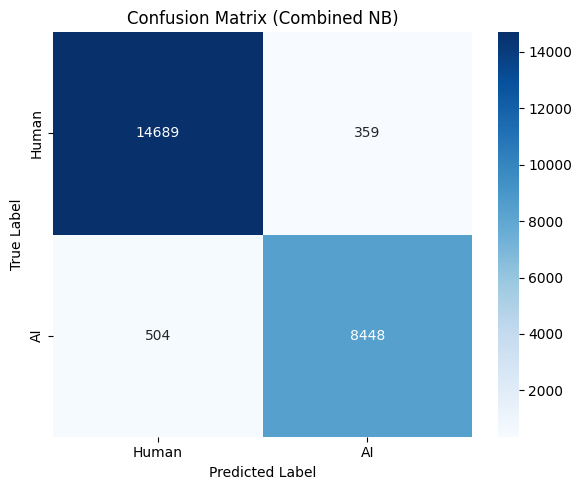

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title('Confusion Matrix (Combined NB)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

The confusion matrix shows the model correctly classified 14,689 human essays and 8,448 AI essays. It misclassified 504 AI essays as human and 359 human essays as AI, meaning it's slightly better at identifying human text than AI text. This makes sense given the class imbalance since the model saw more human examples during the model's training.

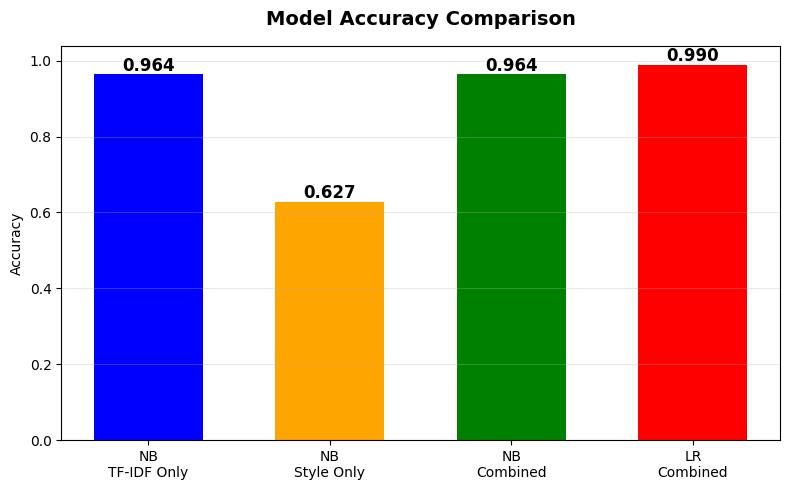

In [ ]:
models = ['NB\nTF-IDF Only', 'NB\nStyle Only', 'NB\nCombined', 'LR\nCombined']
accuracies = [acc_tfidf, acc_style, acc_combined, acc_lr]

colors = ['Blue', 'Orange', 'Green', 'Red']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.6)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,f'{acc:.3f}', ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

The accuracy comparison chart shows that TF-IDF only and the combined model both hit 0.964, meaning adding style features on top of word content didn't really help. Style features alone got a very bad score of only got 0.627. Logistic Regression on the combined features performed the best at 0.990, showing that the choice of model type does matter even when using the same features.


## Conclusion
TF-IDF word features were by far the most effective, hitting 96.4% accuracy on their own which was the same as the combined model. That means adding style features on top of word content didn't really improve the model. Style features alone only managed 62.7% which is barely better than guessing. On the model side, Logistic Regression on the combined features outperformed Naive Bayes at 99.0% showing that the classifier you choose makes a difference even when using the same features.

The top TF-IDF words that drove the models predictions turned out to be the essay topics like "electoral," "college," and "cars" rather than anything related AI specific word choice patterns.

This means the model's high accuracy is mostly coming from topic bias in the dataset where the AI and human essays just happen to cover different subjects. The style differences we found were better (AI uses longer words, higher lexical diversity, less punctuation) but these are too subtle for the model to rely on for an accurate answer.

### Future Work

- **Control for topic** by retraining on a subset where both classes have the same topic distribution to see how much accuracy drops without the topic based shortcut

- **Add more style features** like average paragraph length, transition word density, passive voice frequency, and readability scores like Flesch-Kincaid since our 7 features weren't enough to compete with topic features

- **Try other models** like neural nets or k-clustering that might capture new style patterns that Naive Bayes and Logistic Regression couldn't

- **Test on different types of text** like emails, news articles, or social media posts since our dataset was all essays and the topic bias we found might look completely different with other kinds of writing

- **Compare different LLMs** to see if text from GPT, Claude, Gemini, etc. each have their own detectable style